<a href="https://colab.research.google.com/github/KDNaigan/KD/blob/main/Hands_on_Activity_14_1_Build_a_Narrative_on_a_Storyboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Social Media, Academic Performance**

# STEP 1: THE PROBLEM

We need to find out how the amount of time spend on social media affects students' academic performance (GPA/CGPA) in order to understand its impact and help improve students' study habits and time management.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/survey.csv')

print(df.columns)

df.head()

Index(['Timestamp', 'Age', 'Gender', 'Residence Area  ', 'Education Level',
       'Socioeconomic status (Parent's education level)',
       'Study time (In Hours)', 'Attendance rate (In Percentile)',
       'Social Media Platform', 'Time spent in social media (hours)',
       'Most time spent in a day', 'Physical activity (30 min+) ',
       'Withdrawal symptoms (Side effects of not using social media)',
       'Sleep Disturbance on Sleep Quality', 'Mood Modification Scale',
       'Anxiety Scale ', 'Depression Scale', 'Self-esteem Scale',
       'Last Academic Result (GPA/CGPA)',
       'Social Media Distraction During Academic Activities ', 'Column 19'],
      dtype='object')


,Timestamp,Age,Gender,Residence Area,Education Level,Socioeconomic status (Parent's education level),Study time (In Hours),Attendance rate (In Percentile),Social Media Platform,Time spent in social media (hours),...,Physical activity (30 min+),Withdrawal symptoms (Side effects of not using social media),Sleep Disturbance on Sleep Quality,Mood Modification Scale,Anxiety Scale,Depression Scale,Self-esteem Scale,Last Academic Result (GPA/CGPA),Social Media Distraction During Academic Activities,Column 19
0,26/04/2025 01:14:36,28,Male,Urban,Tertiary Education,Tertiary Education,2,80,YouTube,4,...,Yes,Feeling restless,4,3,4,5,4,3.55,5,NaN
1,26/04/2025 01:24:20,21,Male,Rural,Tertiary Education,No education,3,60,Instagram,5,...,Yes,No symtoms,5,2,2,1,5,3.1,3,NaN
2,27/04/2025 21:38:37,17,Female,Rural,HSC / A' Level,SSC / O' Level,6-7 hour,70%,YouTube,Highest 2 hour,...,Yes,Cravings,1,2,2,1,1,A-,1,NaN
3,27/04/2025 21:42:51,22,Male,Urban,Tertiary Education,HSC / A' Level,1-2hrs,80%,Facebook,6hrs,...,Yes,Feeling restless,3,2,3,3,3,gpa 5/5,1,NaN
4,27/04/2025 21:46:22,26,Male,Urban,Tertiary Education,Tertiary Education,2,85,Facebook,5,...,No,Cravings,4,3,4,3,4,2.78,4,NaN


# STEP 2: STATEMENT QUESTION

How does time spent on social media influence students' academic performance (GPA/CGPA)?

In [ ]:
for col in df.columns:
    print(col)

Timestamp
Age
Gender
Residence Area  
Education Level
Socioeconomic status (Parent's education level)
Study time (In Hours)
Attendance rate (In Percentile)
Social Media Platform
Time spent in social media (hours)
Most time spent in a day
Physical activity (30 min+) 
Withdrawal symptoms (Side effects of not using social media)
Sleep Disturbance on Sleep Quality
Mood Modification Scale
Anxiety Scale 
Depression Scale
Self-esteem Scale
Last Academic Result (GPA/CGPA)
Social Media Distraction During Academic Activities 
Column 19


In [ ]:
print("Social Media Column Exists:", 'Time spent in social media (hours)' in df.columns)
print("GPA Column Exists:", 'Last Academic Result (GPA/CGPA)' in df.columns)

Social Media Column Exists: True
GPA Column Exists: True


#STEP 3: FIND DATA

In [ ]:
df['Time spent in social media (hours)'] = pd.to_numeric(
    df['Time spent in social media (hours)'],
    errors='coerce'
)

In [ ]:
def clean_gpa(x):
    if pd.isna(x):
        return None
    x = str(x)

    # remove common text words manually
    x = x.replace("GPA", "").replace("HSC", "").replace("CGPA", "")

    # split by space or slash and take first part
    parts = x.replace("-", " ").replace("/", " ").split()

    for p in parts:
        try:
            return float(p)
        except:
            continue
    return None

df['clean_gpa'] = df['Last Academic Result (GPA/CGPA)'].apply(clean_gpa)

In [ ]:
df['clean_gpa'] = (
    df['Last Academic Result (GPA/CGPA)']
    .astype(str)
    .str.replace("GPA", "")
    .str.replace("CGPA", "")
    .str.replace("HSC", "")
    .str.replace("-", " ")
    .str.split()
    .str[0]
)

df['clean_gpa'] = pd.to_numeric(df['clean_gpa'], errors='coerce')

In [ ]:
df_clean = df[['Time spent in social media (hours)', 'clean_gpa']].dropna()

In [ ]:
df_clean.head()

,Time spent in social media (hours),clean_gpa
0,4.0,3.55
1,5.0,3.10
4,5.0,2.78
6,8.0,3.91
7,6.0,3.65


The data was purged with the help of Pandas string functions and number conversion. The invalid entries were changed to NaN with the to_numeric(errors=coerce) replacement functions, and the non-numeric characters were removed manually. The values that were missing were removed to provide proper analysis.

# STEP 4: VISUALIZE

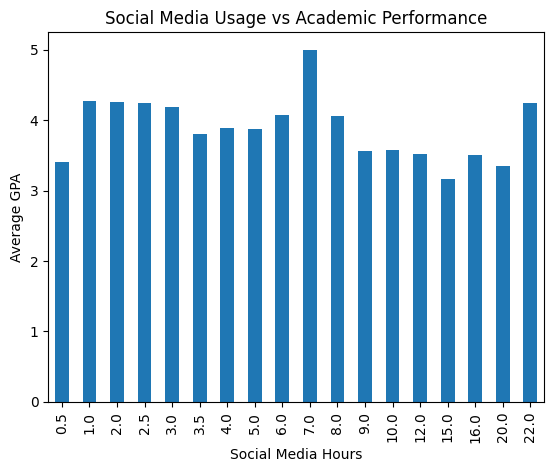

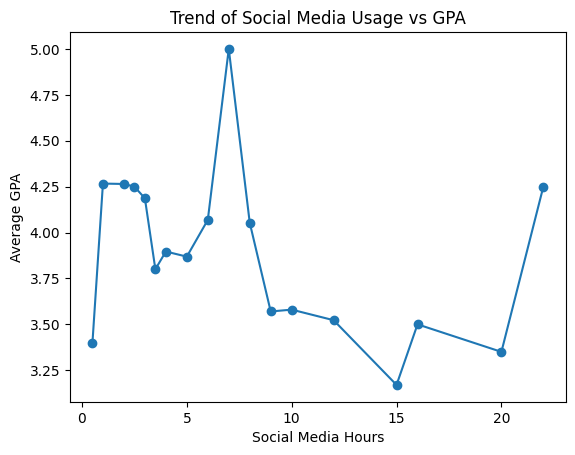

In [ ]:
import matplotlib.pyplot as plt

# Group data
grouped = df_clean.groupby('Time spent in social media (hours)')['clean_gpa'].mean()

# Bar Graph
plt.figure()
grouped.plot(kind='bar')
plt.xlabel('Social Media Hours')
plt.ylabel('Average GPA')
plt.title('Social Media Usage vs Academic Performance')
plt.show()

# Line Graph
plt.figure()
grouped.sort_index().plot(kind='line', marker='o')
plt.xlabel('Social Media Hours')
plt.ylabel('Average GPA')
plt.title('Trend of Social Media Usage vs GPA')
plt.show()

# SUPPLEMENTARY

| Objective                    | Dataset Variable                    |
| ---------------------------- | ----------------------------------- |
| Measure social media usage   | Time spent in social media (hours)  
| Measure academic performance | GPA/CGPA                            |
| Explain contributing factors | Study time, distraction, attendance |


In [ ]:
# Select relevant columns
df_mapping = df[['Time spent in social media (hours)', 'clean_gpa']]

# Describe dataset
df_mapping.describe()

,Time spent in social media (hours),clean_gpa
count,142.000000,397.000000
mean,4.545775,9.262670
std,3.287039,101.227753
min,0.500000,1.890000
25%,2.625000,3.670000
50%,4.000000,4.000000
75%,5.000000,4.920000
max,22.000000,2021.000000


# DATA SOURCE ( CITATION)

Dataset: Survery.csv (Student Social Media Survey Dataset)

Source: Kaggle (https://www.kaggle.com/datasets/mr101rror/student-social-media-academic-performance-dataset)

The dataset was obtained from a survey of students, containing responses on social media usage, academic performance, and study behavior

# WHAT DO YOU AIM TO PROVE?

In [ ]:
# Check relationship
correlation = df_clean.corr()
print(correlation)

                                    Time spent in social media (hours)  \
Time spent in social media (hours)                             1.00000   
clean_gpa                                                     -0.18715   

                                    clean_gpa  
Time spent in social media (hours)   -0.18715  
clean_gpa                             1.00000  


- Higher time spent on social media is associated with changes (often decline) in GPA

- Social media can act as a distraction during academic activities

- Better time management leads to better academic performance

# NARRATIVE

In [ ]:
print(grouped)

Time spent in social media (hours)
0.5     3.400000
1.0     4.266667
2.0     4.264444
2.5     4.250000
3.0     4.186538
3.5     3.800000
4.0     3.896522
5.0     3.868696
6.0     4.068667
7.0     5.000000
8.0     4.053333
9.0     3.570000
10.0    3.580000
12.0    3.522500
15.0    3.170000
16.0    3.500000
20.0    3.350000
22.0    4.250000
Name: clean_gpa, dtype: float64


**In the era of digitalization, social media has taken up a significant role in the lives of students. According to the survey data, students use social media differently, spending more or less time on social media, which can influence academic results. Through comparing the time spent online with GPA, trends are observed with the higher the usage, the higher the academic results. Despite the entertainment and communication offered by the social media, overuse can cause distractions and less time to study. This shows the need to strike a balance between social media exploitation and school work to record improved school performance.**